In [25]:
#Министерство цифрового развития, связи и массовых коммуникаций Российской Федерации
#Федеральное государственное бюджетное образовательное учреждение высшего образования
#«Сибирский государственный университет телекоммуникаций и информатики»
#(СибГУТИ)

#кафедра ММ и ЦРБС

#Практическое занятие №7: Машинное обучение с scikitlearn I

#Выполнил: студент 
#группы МГИ-52
#Яковлев Д.В.
#Проверил преподаватель:
#Фигура К.Н.

#Новосибирск, 2026

#Цели занятия: 
#1. Обучающая: Сформировать у студентов практические навыки подготовки данных для решения задач машинного обучения: выделение признаков (матрица X) и целевой переменной (y), разделение набора данных на обучающую и тестовую выборки с помощью функции train_test_split(). 
#2. Развивающая: Научить студентов применять алгоритмы линейной регрессии и k-ближайших соседей (k-NN) для решения задач регрессии и классификации, а также осознанно выбирать между ними в зависимости от характера данных. 
#3. Воспитательная: Привить культуру объективной оценки моделей машинного обучения, акцентировать внимание на недопустимости использования тестовых данных в процессе обучения. 

#Вариант 7: Физические упражнения Linnerud (задача регрессии с множеством целевых переменных)
#• Датасет: load_linnerud() из sklearn.datasets 
#• Цель: прогнозирование количества подтягиваний, приседаний и прыжков по физическим показателям. 
#• Особенность: использовать MultiOutputRegressor с LinearRegression для предсказания всех трёх целевых переменных сразу. 


In [6]:
# Импорт библиотек 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_linnerud
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from IPython.display import display, Markdown

RANDOM_STATE = 42

In [7]:
# Загрузка датасета
linnerud = load_linnerud()

X = pd.DataFrame(linnerud.data, columns=linnerud.feature_names)
y = pd.DataFrame(linnerud.target, columns=linnerud.target_names)

display(Markdown("**Датасет Linnerud**"))
print(f"Признаки (X): {linnerud.feature_names}")
print(f"Целевые переменные (y): {linnerud.target_names}")
print(f"\nРазмерность X: {X.shape}  →  {X.shape[0]} объектов, {X.shape[1]} признака")
print(f"Размерность y: {y.shape}  →  {y.shape[0]} объектов, {y.shape[1]} целевые переменные")

**Датасет Linnerud**

Признаки (X): ['Chins', 'Situps', 'Jumps']
Целевые переменные (y): ['Weight', 'Waist', 'Pulse']

Размерность X: (20, 3)  →  20 объектов, 3 признака
Размерность y: (20, 3)  →  20 объектов, 3 целевые переменные


In [8]:
# Первичный анализ данных
display(Markdown("**Первые строки признаков (X)**"))
print(X.head())

display(Markdown("**Первые строки целевых переменных (y)**"))
print(y.head())

display(Markdown("**Статистика признаков**"))
print(X.describe())

display(Markdown("**Статистика целевых переменных**"))
print(y.describe())

display(Markdown("**Пропущенные значения в X**"))
print(X.isnull().sum())

display(Markdown("**Пропущенные значения в y**"))
print(y.isnull().sum())

display(Markdown("**Типы данных**"))
print(X.dtypes)

**Первые строки признаков (X)**

   Chins  Situps  Jumps
0    5.0   162.0   60.0
1    2.0   110.0   60.0
2   12.0   101.0  101.0
3   12.0   105.0   37.0
4   13.0   155.0   58.0


**Первые строки целевых переменных (y)**

   Weight  Waist  Pulse
0   191.0   36.0   50.0
1   189.0   37.0   52.0
2   193.0   38.0   58.0
3   162.0   35.0   62.0
4   189.0   35.0   46.0


**Статистика признаков**

...

Chins     0
Situps    0
Jumps     0
dtype: int64


**Пропущенные значения в y**

Weight    0
Waist     0
Pulse     0
dtype: int64


**Типы данных**

Chins     float64
Situps    float64
Jumps     float64
dtype: object


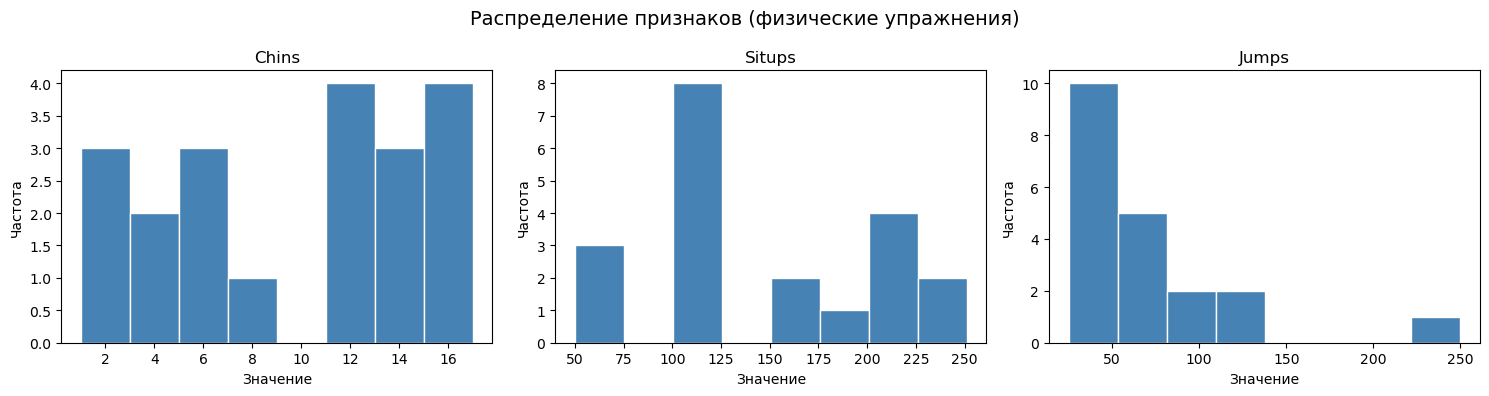

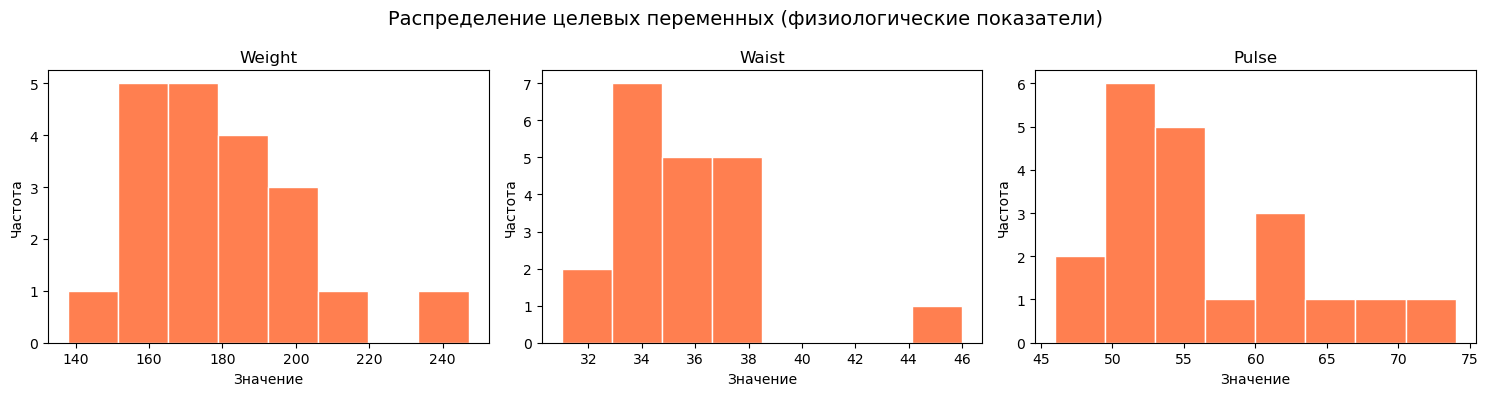

In [9]:
# Визуализация данных 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Распределение признаков (физические упражнения)", fontsize=14)

for i, col in enumerate(X.columns):
    axes[i].hist(X[col], bins=8, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel("Значение")
    axes[i].set_ylabel("Частота")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Распределение целевых переменных (физиологические показатели)", fontsize=14)

for i, col in enumerate(y.columns):
    axes[i].hist(y[col], bins=8, color='coral', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel("Значение")
    axes[i].set_ylabel("Частота")

plt.tight_layout()
plt.show()

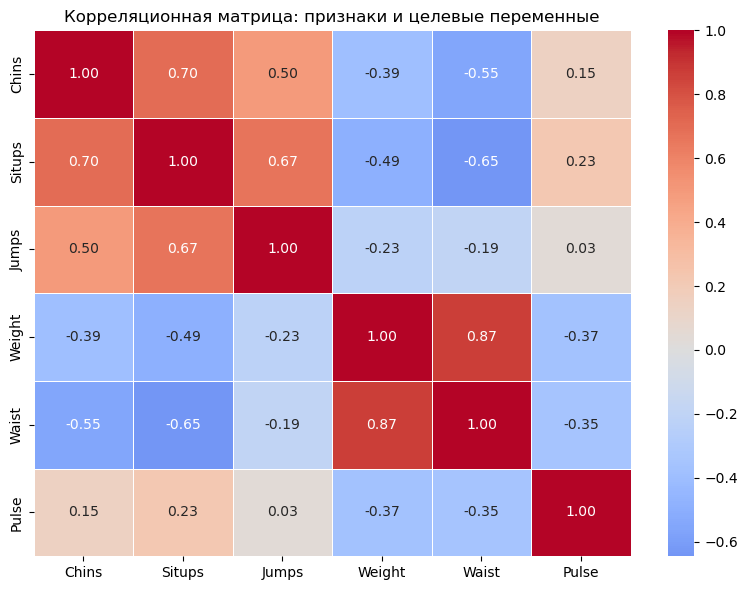

In [10]:
# Корреляционная матрица
combined = pd.concat([X, y], axis=1)

plt.figure(figsize=(8, 6))
sns.heatmap(
    combined.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Корреляционная матрица: признаки и целевые переменные")
plt.tight_layout()
plt.show()

In [11]:
# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

display(Markdown("**Размеры выборок**"))
print(f"Обучающая выборка:  X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Тестовая выборка:   X_test={X_test.shape},  y_test={y_test.shape}")
print(f"\nДоля тестовой выборки: {X_test.shape[0] / X.shape[0]:.0%}")
print(f"Всего объектов в датасете: {X.shape[0]}")

**Размеры выборок**

Обучающая выборка:  X_train=(16, 3), y_train=(16, 3)
Тестовая выборка:   X_test=(4, 3),  y_test=(4, 3)

Доля тестовой выборки: 20%
Всего объектов в датасете: 20


In [12]:
# Масштабирование признаков 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

display(Markdown("**Масштабирование выполнено**"))
print(f"Среднее по train (до):    {X_train.mean().values.round(2)}")
print(f"Среднее по train (после): {X_train_scaled.mean(axis=0).round(4)}")

**Масштабирование выполнено**

Среднее по train (до):    [  9.94 137.44  67.88]
Среднее по train (после): [-0.  0.  0.]


In [14]:
# Модель 1 — без масштабирования
model_raw = MultiOutputRegressor(LinearRegression())
model_raw.fit(X_train, y_train)

y_pred_raw = model_raw.predict(X_test)
y_pred_raw_df = pd.DataFrame(y_pred_raw, columns=y.columns)

display(Markdown("**Модель 1: LinearRegression без масштабирования**"))
display(Markdown("**Предсказания vs Реальные значения**"))

comparison = y_test.reset_index(drop=True).copy()
for col in y.columns:
    comparison[f"{col}_pred"] = y_pred_raw_df[col].values
print(comparison)

**Модель 1: LinearRegression без масштабирования**

**Предсказания vs Реальные значения**

   Weight  Waist  Pulse  Weight_pred  Waist_pred  Pulse_pred
0   191.0   36.0   50.0   166.299446   34.349313   61.692687
1   157.0   32.0   52.0   149.165443   31.140784   64.132980
2   202.0   37.0   62.0   159.626702   33.151725   59.782455
3   189.0   37.0   52.0   181.509420   37.106506   58.293805


In [15]:
# Метрики 
def evaluate_multioutput(y_true, y_pred, target_names, model_name):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    results = []
    display(Markdown(f"**{model_name}**"))
    print(f"{'Переменная':<12} {'MSE':>10} {'MAE':>10} {'R²':>10}")
    print("-" * 45)

    for i, name in enumerate(target_names):
        mse = mean_squared_error(y_true[:, i], y_pred[:, i])
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
        r2  = r2_score(y_true[:, i], y_pred[:, i])
        results.append({"target": name, "MSE": mse, "MAE": mae, "R2": r2})
        print(f"{name:<12} {mse:>10.2f} {mae:>10.2f} {r2:>10.3f}")

    avg_mse = np.mean([r["MSE"] for r in results])
    avg_mae = np.mean([r["MAE"] for r in results])
    avg_r2  = np.mean([r["R2"]  for r in results])
    print("-" * 45)
    print(f"{'Среднее':<12} {avg_mse:>10.2f} {avg_mae:>10.2f} {avg_r2:>10.3f}")

    return results

metrics_raw = evaluate_multioutput(
    y_test, y_pred_raw,
    linnerud.target_names,
    "Метрики: LinearRegression без масштабирования"
)

**Метрики: LinearRegression без масштабирования**

Переменная          MSE        MAE         R²
---------------------------------------------
Weight           630.78      20.60     -1.243
Waist              4.57       1.62     -0.076
Pulse             82.11       8.08     -2.732
---------------------------------------------
Среднее          239.15      10.10     -1.350


In [16]:
# Модель 2 — со масштабированием
model_scaled = MultiOutputRegressor(LinearRegression())
model_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = model_scaled.predict(X_test_scaled)

metrics_scaled = evaluate_multioutput(
    y_test, y_pred_scaled,
    linnerud.target_names,
    "Метрики: LinearRegression со StandardScaler"
)

**Метрики: LinearRegression со StandardScaler**

Переменная          MSE        MAE         R²
---------------------------------------------
Weight           630.78      20.60     -1.243
Waist              4.57       1.62     -0.076
Pulse             82.11       8.08     -2.732
---------------------------------------------
Среднее          239.15      10.10     -1.350


In [17]:
# Коэффициенты подмоделей
display(Markdown("**Коэффициенты линейных моделей (масштабированные признаки)**"))

for i, estimator in enumerate(model_scaled.estimators_):
    target = linnerud.target_names[i]
    coef_df = pd.Series(estimator.coef_, index=linnerud.feature_names)
    display(Markdown(f"**Целевая переменная: {target}**"))
    print(f"  Свободный член (intercept): {estimator.intercept_:.3f}")
    for feat, coef in coef_df.items():
        direction = "↑" if coef > 0 else "↓"
        print(f"  {feat:<10}: {coef:>8.3f}  {direction}")
    print()

**Коэффициенты линейных моделей (масштабированные признаки)**

**Целевая переменная: Weight**

  Свободный член (intercept): 177.062
  Chins     :    2.369  ↑
  Situps    :  -19.585  ↓
  Jumps     :    4.938  ↑



**Целевая переменная: Waist**

  Свободный член (intercept): 35.375
  Chins     :   -0.411  ↓
  Situps    :   -2.983  ↓
  Jumps     :    1.518  ↑



**Целевая переменная: Pulse**

  Свободный член (intercept): 56.625
  Chins     :   -2.540  ↓
  Situps    :    5.732  ↑
  Jumps     :   -2.717  ↓



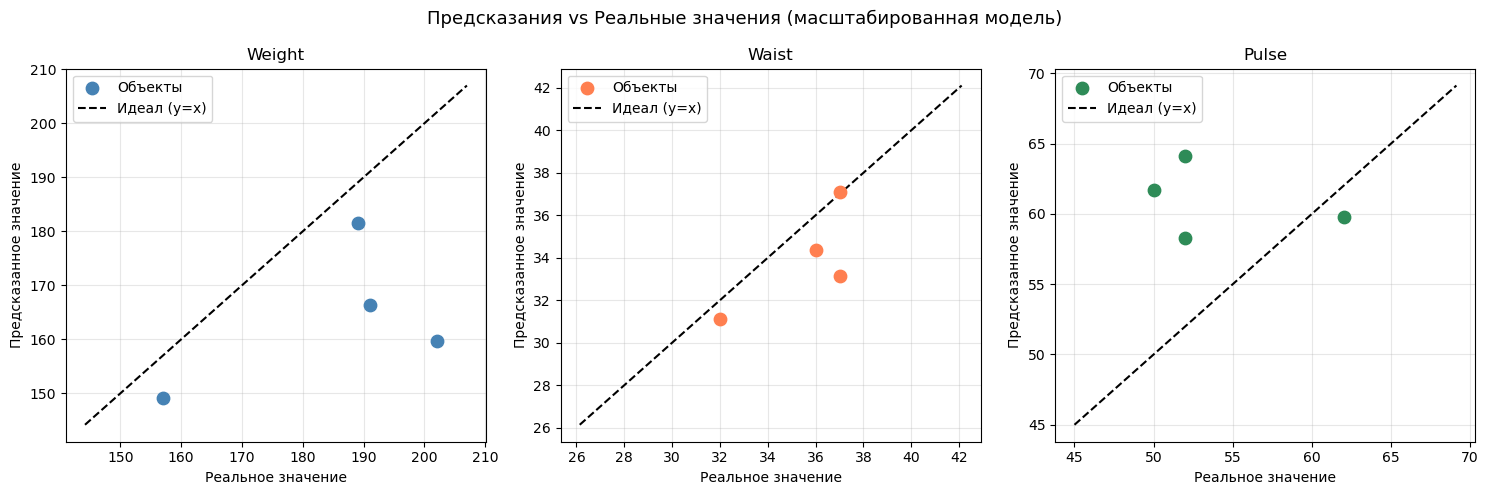

In [18]:
# Предсказания vs реальные значения 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Предсказания vs Реальные значения (масштабированная модель)", fontsize=13)

colors = ['steelblue', 'coral', 'seagreen']

for i, (col, color) in enumerate(zip(y.columns, colors)):
    real = np.array(y_test)[:, i]
    pred = y_pred_scaled[:, i]

    axes[i].scatter(real, pred, color=color, s=80, zorder=3, label="Объекты")

    lim_min = min(real.min(), pred.min()) - 5
    lim_max = max(real.max(), pred.max()) + 5
    axes[i].plot([lim_min, lim_max], [lim_min, lim_max],
                 'k--', linewidth=1.5, label="Идеал (y=x)")

    axes[i].set_title(col)
    axes[i].set_xlabel("Реальное значение")
    axes[i].set_ylabel("Предсказанное значение")
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Сравнение двух моделей**

Целевая переменная     Без масштаб.    Со масштаб.    Разница
-------------------------------------------------------
Weight                 -1.243         -1.243    -0.000
Waist                  -0.076         -0.076    -0.000
Pulse                  -2.732         -2.732 +    0.000


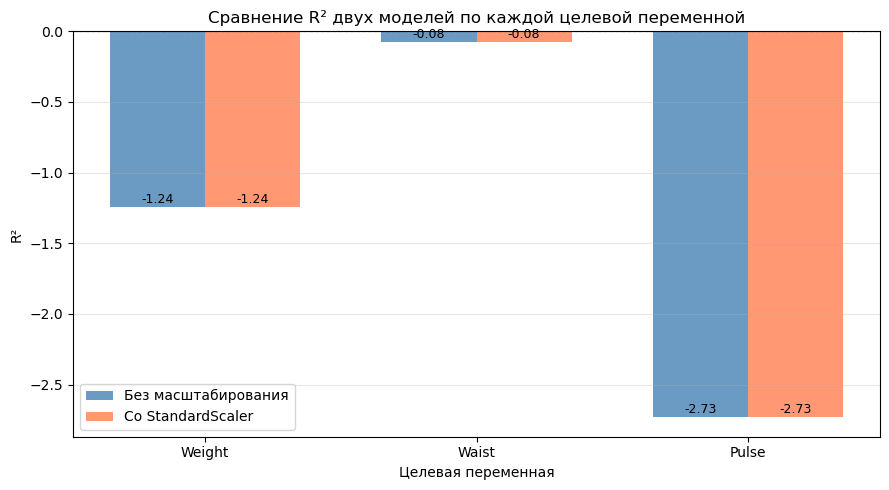

In [19]:
# Сравнение двух моделей
targets = linnerud.target_names

display(Markdown("**Сравнение двух моделей**"))
print(f"{'Целевая переменная':<12} {'Без масштаб.':>16} {'Со масштаб.':>14} {'Разница':>10}")
print("-" * 55)
for i, t in enumerate(targets):
    r2_raw    = metrics_raw[i]["R2"]
    r2_scaled = metrics_scaled[i]["R2"]
    diff = r2_scaled - r2_raw
    sign = "+" if diff >= 0 else ""
    print(f"{t:<12} {r2_raw:>16.3f} {r2_scaled:>14.3f} {sign}{diff:>9.3f}")

x = np.arange(len(targets))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, [r["R2"] for r in metrics_raw],
               width, label="Без масштабирования", color="steelblue", alpha=0.8)
bars2 = ax.bar(x + width/2, [r["R2"] for r in metrics_scaled],
               width, label="Со StandardScaler", color="coral", alpha=0.8)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel("Целевая переменная")
ax.set_ylabel("R²")
ax.set_title("Сравнение R² двух моделей по каждой целевой переменной")
ax.set_xticks(x)
ax.set_xticklabels(targets)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

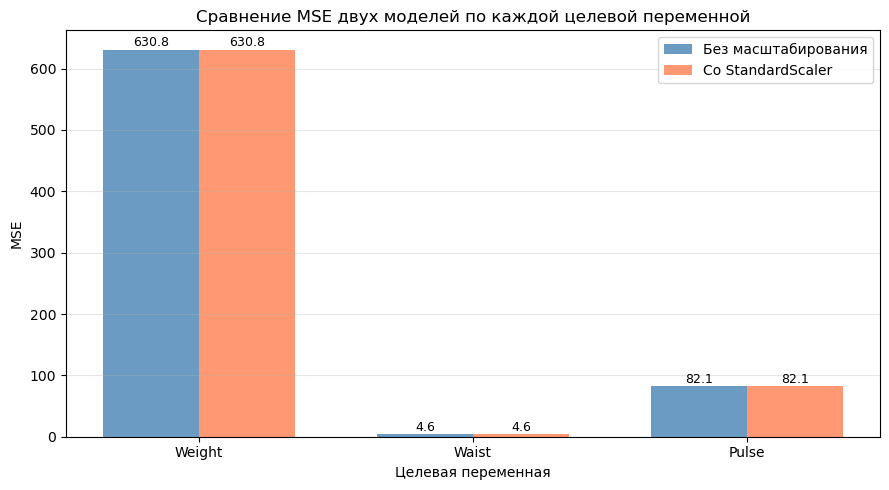

In [20]:
# Сравнение MSE двух моделей 
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, [r["MSE"] for r in metrics_raw],
               width, label="Без масштабирования", color="steelblue", alpha=0.8)
bars2 = ax.bar(x + width/2, [r["MSE"] for r in metrics_scaled],
               width, label="Со StandardScaler", color="coral", alpha=0.8)

ax.set_xlabel("Целевая переменная")
ax.set_ylabel("MSE")
ax.set_title("Сравнение MSE двух моделей по каждой целевой переменной")
ax.set_xticks(x)
ax.set_xticklabels(targets)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}", ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()